In [2]:
pip install pyodbc

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pyodbc
print([x for x in pyodbc.drivers() if 'SQL Server' in x])

['SQL Server', 'ODBC Driver 18 for SQL Server']


In [2]:
import pyodbc

# Forçar a ligação via IP numérico e definir a porta standard do SQL Server (,1433)
conn_str = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=192.168.160.144,1433;"   # <--- Usar o IP descoberto + porta TCP separada por vírgula
    "DATABASE=team_09;"
    "UID=team_09;"                   # Se der erro de login com team_09, muda para sbd24_112944
    "PWD=spring;"                   # Se mudares o UID, lembra-te de mudar para a password 'pascoa'
    "TrustServerCertificate=yes;"
    "Encrypt=no;"
)

# Testar a conexão
try:
    conn = pyodbc.connect(conn_str)
    print("Sucesso! Ligação estabelecida com o servidor do DETI.")
    # O teu código para gerar os gráficos corre aqui...
    conn.close()
except Exception as e:
    print(f"Erro ao ligar: {e}")

Sucesso! Ligação estabelecida com o servidor do DETI.


Ligação ativa! A processar as queries analíticas...
A gerar o Ex1 (Gráfico de Linhas)...


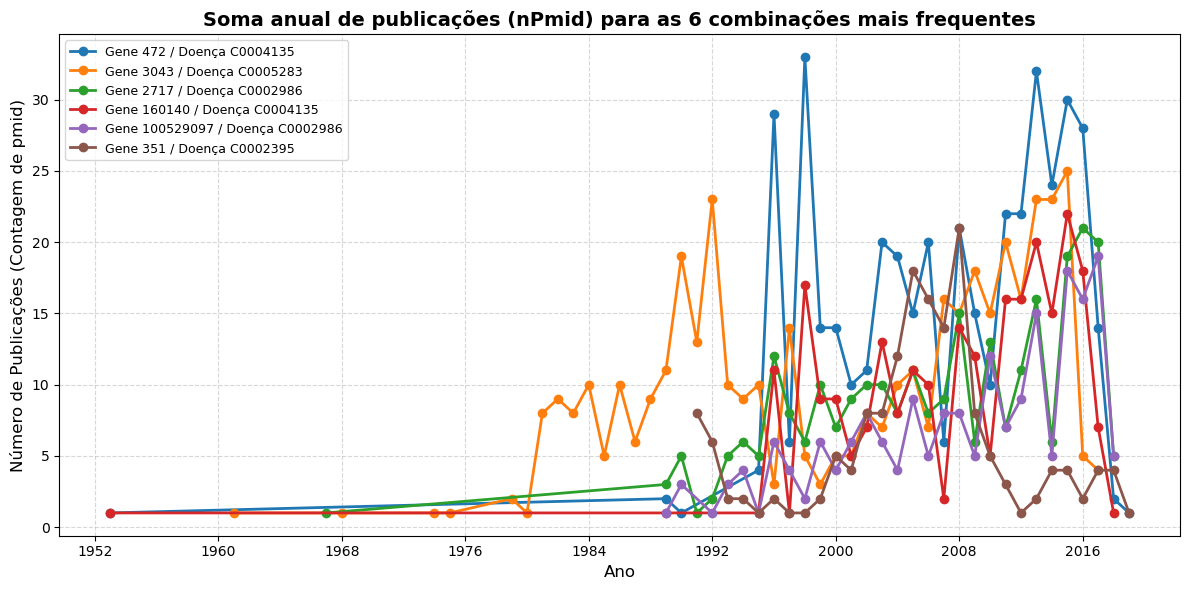

A gerar o Ex2 (Histograma)...


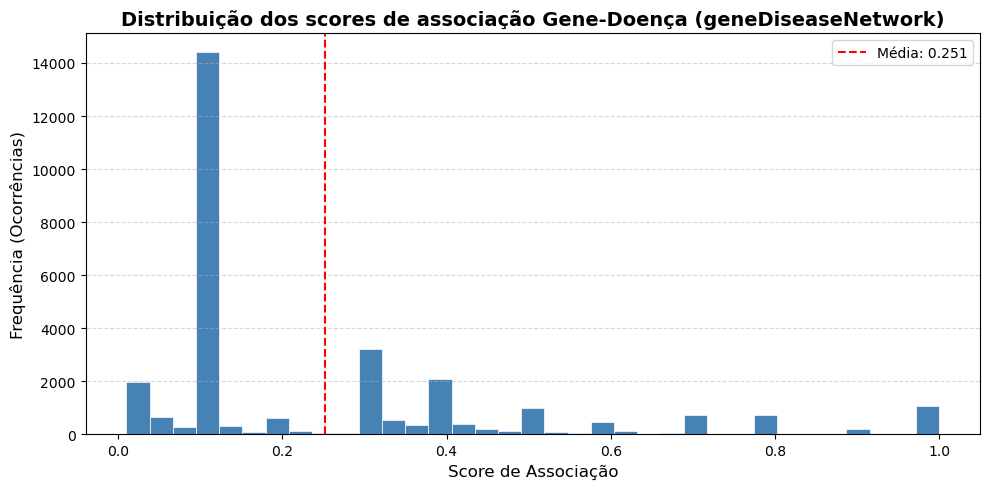

Notebook executado com sucesso e gráficos salvos localmente!


In [ ]:
# Ex1: Gráfico de linhas - número anual de publicações (pmid)
# Ex2: Histograma - distribuição de scores

import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

# Suprimir avisos estéticos do Pandas sobre o SQLAlchemy
warnings.filterwarnings('ignore', category=UserWarning)

# --- Ligação validada e funcional ---
conn_str = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=192.168.160.144,1433;"
    "DATABASE=team_09;"
    "UID=team_09;"
    "PWD=spring;"
    "TrustServerCertificate=yes;"
    "Encrypt=no;"
)

try:
    conn = pyodbc.connect(conn_str)
    print("Ligação ativa! A processar as queries analíticas...")

    # Ex1 — Gráfico de linhas: contagem anual de pmid para 6 combinações
    
    print("A gerar o Ex1 (Gráfico de Linhas)...")
    
    # Alterado SUM(n.pmid) para COUNT(n.pmid) para evitar o estouro de INT (Arithmetic overflow)
    # e refletir corretamente a métrica de volume de publicações (nPmid)
    query_ex1 = """
        SELECT TOP 6 g.geneId, d.diseaseId
        FROM geneDiseaseNetwork n
        JOIN geneAttributes g ON n.geneNID = g.geneNID
        JOIN diseaseAttributes d ON n.diseaseNID = d.diseaseNID
        WHERE n.pmid IS NOT NULL
        GROUP BY g.geneId, d.diseaseId
        ORDER BY COUNT(n.pmid) DESC;
    """
    top6 = pd.read_sql(query_ex1, conn)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Para cada uma das 6 combinações de topo, vamos buscar o histórico anual de volume
    for _, row in top6.iterrows():
        query_dados = """
            SELECT n.year, COUNT(n.pmid) AS total_nPmid
            FROM geneDiseaseNetwork n
            JOIN geneAttributes g ON n.geneNID = g.geneNID
            JOIN diseaseAttributes d ON n.diseaseNID = d.diseaseNID
            WHERE g.geneId = ? AND d.diseaseId = ? AND n.pmid IS NOT NULL AND n.year IS NOT NULL
            GROUP BY n.year
            ORDER BY n.year;
        """
        df_linhas = pd.read_sql(query_dados, conn, params=[row['geneId'], row['diseaseId']])
        label = f"Gene {row['geneId']} / Doença {row['diseaseId']}"
        ax.plot(df_linhas['year'], df_linhas['total_nPmid'], marker='o', linewidth=2, label=label)

    ax.set_title('Soma anual de publicações (nPmid) para as 6 combinações mais frequentes', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Número de Publicações (Contagem de pmid)', fontsize=12)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    
    # Guarda o gráfico como imagem conforme as exigências do projeto
    plt.savefig('ex1_linha_npmid.png', dpi=150)
    plt.show()

  
    # Ex2 — Histograma: distribuição de scores
    print("A gerar o Ex2 (Histograma)...")
    
    query_ex2 = "SELECT score FROM geneDiseaseNetwork WHERE score IS NOT NULL;"
    df_hist = pd.read_sql(query_ex2, conn)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df_hist['score'], bins=35, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title('Distribuição dos scores de associação Gene-Doença (geneDiseaseNetwork)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Score de Associação', fontsize=12)
    ax.set_ylabel('Frequência (Ocorrências)', fontsize=12)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    mean_score = df_hist['score'].mean()
    ax.axvline(mean_score, color='red', linestyle='--', linewidth=1.5, label=f'Média: {mean_score:.3f}')
    ax.legend()
    plt.tight_layout()
    
    # Guarda o histograma como imagem
    plt.savefig('ex2_histograma_score.png', dpi=150)
    plt.show()

    conn.close()
    print("Notebook executado com sucesso e gráficos salvos localmente!")

except Exception as e:
    print(f"\nErro durante a execução do pipeline analítico: {e}")